In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import numpy as np

from matplotlib import pyplot as plt

import seaborn as sns

from matplotlib_venn import venn3

import statsmodels.api as sm

import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import descri_function as des_fun

In [2]:
# dado com os modelos 
#df = pd.read_parquet("/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/aesop_27_03_2026_with_MEM_EVI.parquet")
df = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/aesop_06_05_2026_with_MEM_all_mods_ens.parquet')

dta = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/cities_valid_for_MEM_26_03_2026.parquet')


#df_ens_and = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/resultado_13-04-2026_mlp_xgb_withConsec.parquet')
df_ens_and = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/resultado_predicoes_producao_mlp.parquet')

df_ens_and = df_ens_and[['co_ibge', 'year_week','prob_ensemble_xgb', 'signal_ensemble_xgb50', 'prob_ensemble_mlp',
       'signal_ensemble_mlp50']]
#df_ens_and = df_ens_and.rename(columns={'prob_ensemble_xgb':'prob_ensemble_xgb2', 'signal_ensemble_xgb50': 'signal_ensemble_xgb502', 
#                           'prob_ensemble_mlp':'prob_ensemble_mlp2', 'signal_ensemble_mlp50':'signal_ensemble_mlp502'})

df_merged = df.merge(df_ens_and, on=['co_ibge', 'year_week'], how='inner')

df = df_merged.copy()

# Select cities for the manuscript analysis (valid MEM)
lst = list(set(df.co_ibge.unique()) - set(dta.co_ibge.unique()))
df = df[~df.co_ibge.isin(lst)]

df =  df[(df.year_week >= '2022-42') &(df.year_week <= '2025-32')]

In [3]:
# Classify MEM surges accordingly to intensity
df_mem = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/mem_output_26_03_2026.parquet')

df_mem = df_mem[df_mem.epiyear.isin([2022,2023, 2024,2025])]

dta_intens = df_mem.groupby(['co_ibge'])[['baseline', 'post_baseline', 'epidemic_threshold',
       'post_threshold', 'low_level', 'medium_level', 'high_level']].max().reset_index()

In [4]:
# FUNCTION TO ASSIGN INTENSITY

def classify_block(values):
    
    # Check from most severe to least
    if (values > high).any():
        return 'very high'
    
    elif (values > med).any():
        return 'high'
    
    elif (values > low).any():
        return 'medium'
    
    elif (values > epi).any():
        return 'low'
    
    elif ((values > base) & (values <= epi)).any():
        return 'very low'
    
    elif (values <= base).any():
        return 'baseline'
    
    return np.nan


In [5]:
import warnings
warnings.filterwarnings('ignore')

lst = []

for code in df.co_ibge.unique():

    #print(code)

    set_muni = df[df.co_ibge == code].copy()
    set_muni_inten = dta_intens[dta_intens.co_ibge == code]

    thresholds = set_muni_inten.iloc[0]

    #base = thresholds['baseline'].astype(int)
    #epi = thresholds['epidemic_threshold'].astype(int)
    #low = thresholds['low_level'].astype(int)
    #med = thresholds['medium_level'].astype(int)
    #high = thresholds['high_level'].astype(int)
    #very_high = thresholds.get('very_high_level', np.inf)  # fallback if missing

    base = int(thresholds['baseline'])
    epi = int(thresholds['epidemic_threshold'])
    low  = int(thresholds['low_level'])    if pd.notna(thresholds.get('low_level'))    else 2 * epi
    med  = int(thresholds['medium_level']) if pd.notna(thresholds.get('medium_level')) else 4 * epi
    high = int(thresholds['high_level'])   if pd.notna(thresholds.get('high_level'))   else 6 * epi
    very_high = thresholds.get('very_high_level', np.inf)


    set_muni = set_muni.sort_values(['year_week'])

    # IDENTIFY BLOCKS

    flag = set_muni['mem_surge_01_correct_with_consec']

    # Create block IDs for consecutive 1s
    set_muni['block'] = (flag != flag.shift()).cumsum()

    # Keep only blocks where flag == 1
    set_muni['intensity'] = np.nan


    #  APPLY TO EACH BLOCK

    for block_id, group in set_muni.groupby('block'):
    
        if group['mem_surge_01_correct_with_consec'].iloc[0] != 1:
            continue
    
        values = group['atend_ivas']
    
        intensity_label = classify_block(values)
    
        set_muni.loc[group.index, 'intensity'] = intensity_label

    lst.append(set_muni)


In [6]:
result = pd.concat(lst)
result['mem_low'] = ((result['intensity'] == 'low') & (result['warning_final_mem_surge_01'] == 1)).astype(int)
result['mem_medium'] = ((result['intensity'] == 'medium') & (result['warning_final_mem_surge_01'] == 1)).astype(int)
result['mem_high'] = ((result['intensity'] == 'high') & (result['warning_final_mem_surge_01'] == 1)).astype(int)
result['mem_very_high'] = ((result['intensity'] == 'very high') & (result['warning_final_mem_surge_01'] == 1)).astype(int)

In [7]:
result['mem_low_consec'] = ((result['intensity'] == 'low') & (result['mem_surge_01_correct_with_consec'] == 1)).astype(int)
result['mem_medium_consec'] = ((result['intensity'] == 'medium') & (result['mem_surge_01_correct_with_consec'] == 1)).astype(int)
result['mem_high_consec'] = ((result['intensity'] == 'high') & (result['mem_surge_01_correct_with_consec'] == 1)).astype(int)
result['mem_very_high_consec'] = ((result['intensity'] == 'very high') & (result['mem_surge_01_correct_with_consec'] == 1)).astype(int)

In [8]:
result = result[['co_ibge', 'year_week', 'atend_ivas',
       'atend_totais', 'mem_surge_01_correct_with_consec',
       'warning_final_mem_surge_01', 'sinal_ears_atend', 'sinal_evi_ivas',
       'EWS_ISF', 'EWS_LOF', 'EWS_OCSVM', 'EWS_COPOD', 'EWS_Rt', 
       'signal_ensemble_xgb50', 
       'signal_ensemble_mlp50', 'hard_voting_ivas', 
       'risk_probs', 'sinal_ens_ivas_new', 'block', 'intensity', 'mem_low',
       'mem_medium', 'mem_high', 'mem_very_high', 'mem_low_consec',
        'mem_medium_consec','mem_high_consec', 'mem_very_high_consec']]

In [9]:
# select period

data = result[result.year_week >= '2025-01']


models = ['sinal_ears_atend',
          'sinal_evi_ivas',
          'EWS_ISF', 
          'EWS_LOF', 
          'EWS_OCSVM', 
          'EWS_COPOD', 
          'EWS_Rt',
          'signal_ensemble_xgb50',
          'signal_ensemble_mlp50',
          'sinal_ens_ivas_new',
          'hard_voting_ivas'
]

warn_col = 'warning_final_mem_surge_01'

warn_col_with_consec = 'mem_surge_01_correct_with_consec'

# Count anomalies

In [10]:
data[[warn_col,warn_col_with_consec]].sum()

warning_final_mem_surge_01           5765
mem_surge_01_correct_with_consec    33083
dtype: int64

In [11]:
eadms = data[['sinal_ears_atend',
          'sinal_evi_ivas',
          'EWS_ISF', 
          'EWS_LOF', 
          'EWS_OCSVM', 
          'EWS_COPOD', 
          'EWS_Rt',]].sum().to_list()

In [12]:
data[['sinal_ears_atend',
          'sinal_evi_ivas',
          'EWS_ISF', 
          'EWS_LOF', 
          'EWS_OCSVM', 
          'EWS_COPOD', 
          'EWS_Rt',]].sum()

sinal_ears_atend    49654
sinal_evi_ivas      36746
EWS_ISF             23626
EWS_LOF             26385
EWS_OCSVM           24997
EWS_COPOD           23049
EWS_Rt              29763
dtype: int64

In [13]:
print('Mean of anomalies with 95% CI', des_fun.mean_confidence_interval(
   eadms, confidence=0.95
))

Mean of anomalies with 95% CI (30603, 21697, 39508)


In [14]:
#round(29740/33083,1)

In [15]:
ens = data[['signal_ensemble_xgb50',
          'signal_ensemble_mlp50',
          'sinal_ens_ivas_new',
          'hard_voting_ivas']].sum().to_list()

In [16]:
data[['signal_ensemble_xgb50',
          'signal_ensemble_mlp50',
          'sinal_ens_ivas_new',
          'hard_voting_ivas']].sum()

signal_ensemble_xgb50    49946
signal_ensemble_mlp50    52264
sinal_ens_ivas_new       47836
hard_voting_ivas         27676
dtype: int64

In [17]:
print('Mean of anomalies with 95% CI', des_fun.mean_confidence_interval(
   ens, confidence=0.95
))

Mean of anomalies with 95% CI (44430, 26426, 62435)


In [18]:
#round((44429 - 29740)*100/29740,1)

#### Ending descrition

# Starting timing analysis

In [19]:
# Get peformance
lst1 = []
lst2 = []

for sel_model in models:

    print(sel_model)

    df_warning_count = des_fun.antici_count(data, sel_model, warn_col,warn_col_with_consec, 'co_ibge')
    
    performance_summary = des_fun.summarize_performance(df_warning_count)

    performance_summary['model'] = sel_model
    df_warning_count['model'] = sel_model

    lst1.append(performance_summary)
    lst2.append(df_warning_count)
        
summary =  pd.concat(lst1)

sinal_ears_atend
sinal_evi_ivas
EWS_ISF
EWS_LOF
EWS_OCSVM
EWS_COPOD
EWS_Rt
signal_ensemble_xgb50
signal_ensemble_mlp50
sinal_ens_ivas_new
hard_voting_ivas


# See data with timing cols to calculate the CI

In [20]:
dta_tab1 = pd.concat(lst2)

dta_tab1.model = dta_tab1.model.replace({'EWS_COPOD': 'COPOD', 'EWS_ISF': 'ISF',
                         'EWS_LOF':'LOF', 'EWS_OCSVM': 'OCSVM',
                         'EWS_Rt':'NGM', 'sinal_ears_atend': 'EARS',
                         'sinal_evi_ivas': 'EVI',  'warning_ivas_ffa': 'FFA',
                        'signal_ensemble_xgb50': 'XGB',
                         'signal_ensemble_mlp50':'MLP', 'sinal_ens_ivas_new': 'LR',
                                            'hard_voting_ivas': 'MV'})

In [21]:
dta_tab2 = dta_tab1.groupby(['model'])[['n3','n2','n1','n0','missed','total_aih_warning']].sum().reset_index()

In [22]:
# Functon to get CI for timing results
from statsmodels.stats.proportion import proportion_confint


def add_ci(df, col_num, col_total):
    """
    Adds lower and upper 95% CI columns using Wilson method.
    """
    lower, upper = [], []
    for x, n in zip(df[col_num], df[col_total]):
        l, u = proportion_confint(x, n, alpha=0.05, method="wilson")
        lower.append(l * 100)
        upper.append(u * 100)
    df[f"{col_num.replace('_num', '')}_CI_low"] = lower
    df[f"{col_num.replace('_num', '')}_CI_high"] = upper



In [23]:
# Apply to PHC and OTC early/timely/missed
cols_to_ci = ["n3", "n2", "n1",'n0','missed']

dta_tab2[cols_to_ci] = dta_tab2[cols_to_ci ].astype(int)

for col in cols_to_ci:
    add_ci(dta_tab2, col, "total_aih_warning")

dta_tab2 = dta_tab2.assign(n3_per = dta_tab2.n3*100/dta_tab2.total_aih_warning,
                           n2_per = dta_tab2.n2*100/dta_tab2.total_aih_warning,
                           n1_per = dta_tab2.n1*100/dta_tab2.total_aih_warning,
                           n0_per = dta_tab2.n0*100/dta_tab2.total_aih_warning,
                           missed_per = dta_tab2.missed*100/dta_tab2.total_aih_warning,)

In [24]:
round(dta_tab2[['model','missed','missed_per','missed_CI_low','missed_CI_high',]],1)

,model,missed,missed_per,missed_CI_low,missed_CI_high
0,COPOD,1565,27.1,26.0,28.3
1,EARS,835,14.5,13.6,15.4
2,EVI,891,15.5,14.5,16.4
3,ISF,2063,35.8,34.6,37.0
4,LOF,1402,24.3,23.2,25.4
5,LR,508,8.8,8.1,9.6
6,MLP,491,8.5,7.8,9.3
7,MV,1321,22.9,21.8,24.0
8,NGM,1465,25.4,24.3,26.6
9,OCSVM,1856,32.2,31.0,33.4


# Plot

In [25]:
# Custom order for regions/population groups
order = ['COPOD', 'EARS', 'EVI', 'MV', 'ISF', 'LOF', 'FFA','LR', 'MLP',
       'NGM', 'OCSVM', 'XGB']
df_plot = dta_tab2.copy()
# Ensure the 'Region_or_PopSize' column is treated as categorical for correct ordering
df_plot["Model"] = pd.Categorical(df_plot["model"], categories=order, ordered=True)
# Sort in descending order so the plot reads from National (top) to Large (bottom)
df_plot = df_plot.sort_values("Model", ascending=False).reset_index(drop=True)

df_plot = df_plot[['Model', 'n3_per',
       'n3_CI_low', 'n3_CI_high', 'n2_per', 'n2_CI_low', 'n2_CI_high',
        'n1_per', 'n1_CI_low', 'n1_CI_high', 'n0_per', 'n0_CI_low', 'n0_CI_high', 
        'missed_CI_low','missed_CI_high','missed_per']]

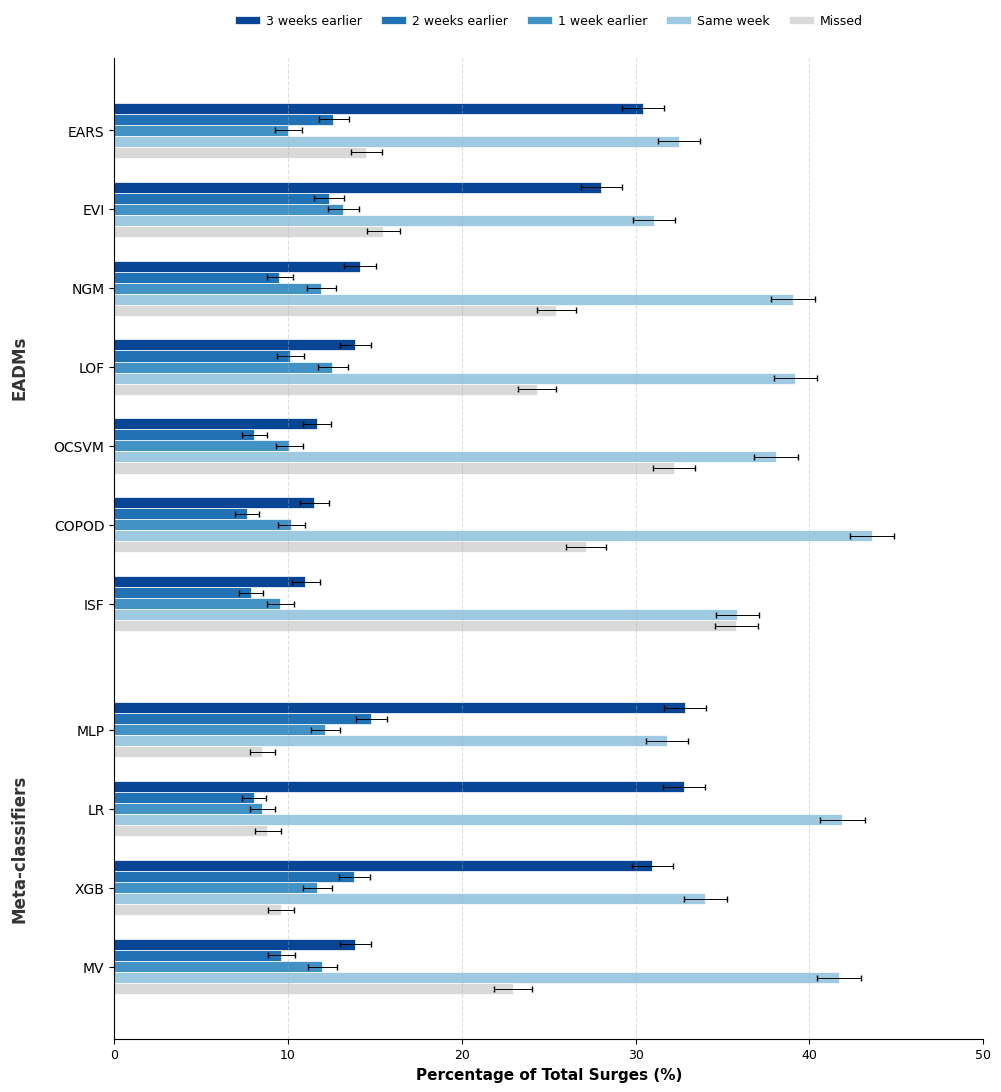

In [26]:

# 2. Agrupamento
ml_ensemble_group = ['XGB', 'LR', 'MV', 'MLP']
df_plot['Group'] = df_plot['Model'].apply(lambda x: 'Meta-classifiers' if x in ml_ensemble_group else 'EADMs')

# Ordenar por grupo para ficarem juntos no gráfico
df_plot = df_plot.sort_values(by=['Group', 'n3_per'], ascending=[True, False]).reset_index(drop=True)

# 3. Configurações de Estilo
plt.rcParams['font.family'] = 'sans-serif'
colors = ['#084594', '#2171b5', '#4292c6', '#9ecae1', '#d9d9d9']
metrics = ['n3', 'n2', 'n1', 'n0', 'missed']
labels = ['3 weeks earlier', '2 weeks earlier', '1 week earlier', 'Same week', 'Missed']

fig, ax = plt.subplots(figsize=(10, 11))

bar_height = 0.14
# Criar índices com um "gap" entre os grupos
indices = []
current_pos = 0
for i in range(len(df_plot)):
    if i > 0 and df_plot.iloc[i]['Group'] != df_plot.iloc[i-1]['Group']:
        current_pos += 0.6  # Espaço extra entre blocos
    indices.append(current_pos)
    current_pos += 1

indices = np.array(indices)

# 4. Plotagem
for i, (metric, label) in enumerate(zip(metrics, labels)):
    per = df_plot[f'{metric}_per']
    errors = [per - df_plot[f'{metric}_CI_low'], df_plot[f'{metric}_CI_high'] - per]
    
    pos = indices + (i * bar_height)
    
    ax.barh(pos, per, bar_height, label=label, color=colors[i], edgecolor='white', linewidth=0.5)
    ax.errorbar(per, pos, xerr=errors, fmt='none', ecolor='black', capsize=2, elinewidth=0.7)

# 5. Estética Final
# Centralizar labels dos modelos no meio do bloco de barras
ax.set_yticks(indices + (bar_height * (len(metrics)-1) / 2))
ax.set_yticklabels(df_plot['Model'], fontsize=10)
ax.invert_yaxis()

ax.set_xlabel('Percentage of Total Surges (%)', fontsize=11, fontweight='bold')
#ax.set_title('Detection Timing', loc='left', fontsize=14, pad=20)
# X-axis cleanup
ax.set_xlim(0, 50) # Assuming percentage
ax.xaxis.set_tick_params(labelsize=9)

# Adicionar labels dos Grupos
for group in df_plot['Group'].unique():
    group_indices = indices[df_plot['Group'] == group]
    avg_pos = group_indices.mean() + (bar_height * 2)
    ax.text(-6, avg_pos, group, fontweight='bold', fontsize=12, rotation=90, va='center', color='#333333')

ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


#ax.legend(title='Timeline', bbox_to_anchor=(1.0, 1.0), loc='upper left', frameon=False)
# --- 5. The Lancet Legend (One row, top) ---
# ncol=5 puts everything in one row; loc='lower center' with bbox_to_anchor 
# puts it above the plot area
ax.legend(
    loc='lower center', 
    bbox_to_anchor=(0.5, 1.02), 
    ncol=5, 
    frameon=False, 
    fontsize=9, 
    handletextpad=0.5,
    columnspacing=1.5
)

plt.tight_layout()
plt.show()

In [27]:
#round(df_plot[df_plot.Model.isin(['MLP','XGBOOST', 'LR'])],1)

df_plot.to_parquet('df_plot_compar_orig.parquet')

In [28]:
df_plot.columns

Index(['Model', 'n3_per', 'n3_CI_low', 'n3_CI_high', 'n2_per', 'n2_CI_low',
       'n2_CI_high', 'n1_per', 'n1_CI_low', 'n1_CI_high', 'n0_per',
       'n0_CI_low', 'n0_CI_high', 'missed_CI_low', 'missed_CI_high',
       'missed_per', 'Group'],
      dtype='object')

# See peformance according intensity

In [29]:
def evaluate_model(df, model_col):

    lst1 = []
    lst2 = []

    for col in ['mem_low', 'mem_medium', 'mem_high', 'mem_very_high']:

        col_consec = col+'_consec'

        df_warning_count = des_fun.antici_count(df, model_col, col, col_consec, 'co_ibge')
        performance_summary = des_fun.summarize_performance(df_warning_count)

        performance_summary['model'] = model_col
        performance_summary['intensity_level'] = col

        df_warning_count['model'] = model_col
        df_warning_count['intensity_level'] = col
        
        lst1.append(performance_summary)
        lst2.append(df_warning_count)
        
    return pd.concat(lst1), pd.concat(lst2)

In [30]:
# loop over models
all_results = []

for model in models:
    print(f'Running model: {model}')
    res_model = evaluate_model(result, model)
    all_results.append(res_model)


Running model: sinal_ears_atend
Running model: sinal_evi_ivas
Running model: EWS_ISF
Running model: EWS_LOF
Running model: EWS_OCSVM
Running model: EWS_Rt
Running model: signal_ensemble_xgb50
Running model: signal_ensemble_mlp50
Running model: sinal_ens_ivas_new
Running model: hard_voting_ivas


In [31]:
lst = []

for i in [0,1,2,3,4,5,6,7,8,9,10]:
    res_dta = all_results[i][1].groupby(['model','intensity_level'])[['n3','n2','n1','n0','missed','total_aih_warning']].sum().reset_index()

    lst.append(res_dta)

In [32]:
dta_tab2 = pd.concat(lst)

In [33]:
# Apply to PHC and OTC early/timely/missed
cols_to_ci = ["n3", "n2", "n1",'n0','missed']

dta_tab2[cols_to_ci] = dta_tab2[cols_to_ci ].astype(int)

for col in cols_to_ci:
    add_ci(dta_tab2, col, "total_aih_warning")

dta_tab2 = dta_tab2.assign(n3_per = dta_tab2.n3*100/dta_tab2.total_aih_warning,
                           n2_per = dta_tab2.n2*100/dta_tab2.total_aih_warning,
                           n1_per = dta_tab2.n1*100/dta_tab2.total_aih_warning,
                           n0_per = dta_tab2.n0*100/dta_tab2.total_aih_warning,
                           missed_per = dta_tab2.missed*100/dta_tab2.total_aih_warning,)

In [34]:
dta_tab2.model = dta_tab2.model.replace({'EWS_COPOD': 'COPOD', 'EWS_ISF': 'ISF',
                         'EWS_LOF':'LOF', 'EWS_OCSVM': 'OCSVM',
                         'EWS_Rt':'NGM', 'sinal_ears_atend': 'EARS',
                         'sinal_evi_ivas': 'EVI', 'signal_ensemble_xgb50': 'XGB',
                         'signal_ensemble_mlp50':'MLP', 'sinal_ens_ivas_new': 'LR',
                                            'hard_voting_ivas': 'MV'})

In [35]:
dta_tab2.intensity_level = dta_tab2.intensity_level.replace({'mem_high': 'High', 
                                                             'mem_low': 'Low',
                                                             'mem_medium': 'Medium', 
                                                             'mem_very_high': 'Very High'})

In [36]:
dta_tab2.intensity_level.unique()

array(['High', 'Low', 'Medium', 'Very High'], dtype=object)

In [37]:
# Custom order for regions/population groups
order = ['COPOD', 'EARS', 'EVI', 'MV', 'ISF', 'LOF', 'LR', 'MLP',
       'NGM', 'OCSVM', 'XGB']
df_plot = dta_tab2.copy()
# Ensure the 'Region_or_PopSize' column is treated as categorical for correct ordering
df_plot["Model"] = pd.Categorical(df_plot["model"], categories=order, ordered=True)
# Sort in descending order so the plot reads from National (top) to Large (bottom)
df_plot = df_plot.sort_values("Model", ascending=False).reset_index(drop=True)

df_plot = df_plot[['Model','intensity_level', 'n3_per',
       'n3_CI_low', 'n3_CI_high', 'n2_per', 'n2_CI_low', 'n2_CI_high',
        'n1_per', 'n1_CI_low', 'n1_CI_high', 'n0_per', 'n0_CI_low', 'n0_CI_high', 
        'missed_CI_low','missed_CI_high','missed_per']]

In [38]:
dta_int_plot = df_plot # parei aqui, veja que preciso pegar as contagens con intervalo anterior para plotar tudo

In [39]:
dta_int_plot.to_csv('anticipation_intensity.csv')

In [40]:
df_plot = df_plot.assign(intensity_level = 'Total')

In [41]:
df_plot = df_plot[['Model', 'n3_per', 'n3_CI_low', 'n3_CI_high', 'n2_per', 'n2_CI_low',
       'n2_CI_high', 'n1_per', 'n1_CI_low', 'n1_CI_high', 'n0_per',
       'n0_CI_low', 'n0_CI_high', 'missed_CI_low', 'missed_CI_high',
       'missed_per', 'intensity_level']]

In [42]:
df_res = pd.concat([df_plot,dta_int_plot ])

In [43]:
df_res[['missed_CI_low', 'missed_CI_high',
       'missed_per']]

,missed_CI_low,missed_CI_high,missed_per
0,5.801336,6.987954,6.368938
1,10.354982,11.763454,11.039558
2,18.637924,20.347447,19.478472
3,7.149204,8.817836,7.943578
4,27.827329,29.862582,28.834275
...,...,...,...
39,20.178544,22.011242,21.080300
40,16.907600,18.765682,17.817680
41,33.402804,35.453429,34.420861
42,20.265202,22.798079,21.504578


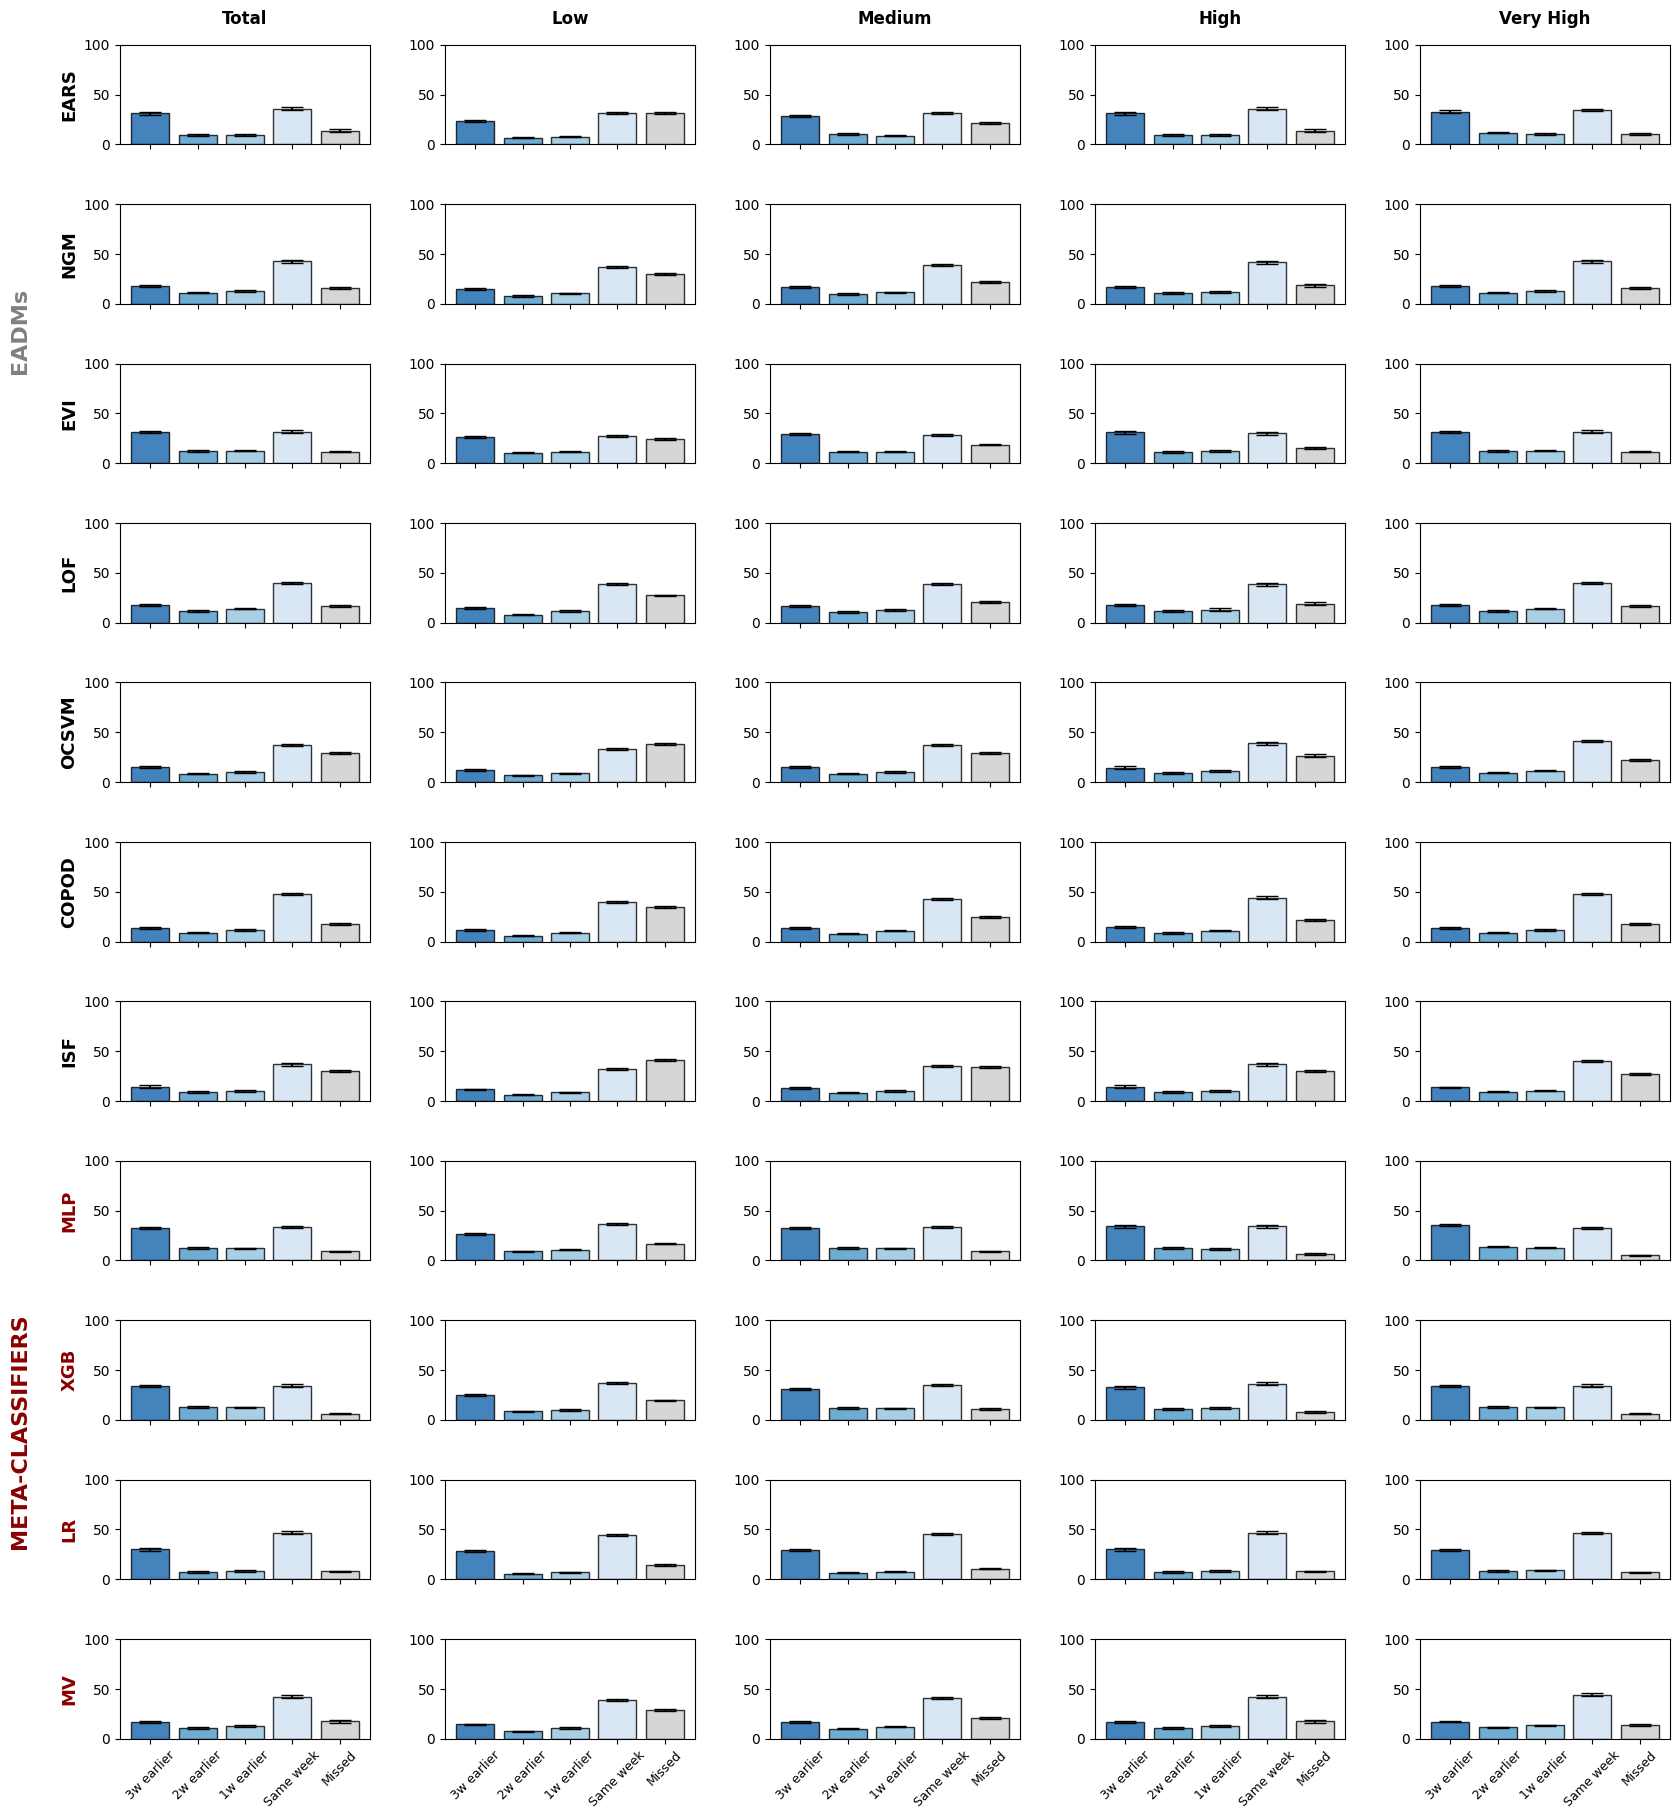

In [74]:

# Define the groups
meta_classifiers = ['MLP', 'XGB', 'LR', 'MV']
eadms = ['EARS', 'NGM', 'EVI', 'LOF', 'OCSVM', 'COPOD', 'ISF'] # Order from your data
all_models = eadms + meta_classifiers

intensities = ['Total', 'Low', 'Medium', 'High', 'Very High']
timeline_labels = ['3w earlier', '2w earlier', '1w earlier', 'Same week', 'Missed']
time_keys = ['n3', 'n2', 'n1', 'n0', 'missed']

# Color palette: Blues for early, grey for missed
colors = sns.color_palette("Blues_r", 4) + [(0.8, 0.8, 0.8)]

# Setup the grid: rows = models, cols = intensities
fig, axes = plt.subplots(len(all_models), 5, figsize=(20, 22), sharex=True)
plt.subplots_adjust(hspace=0.6, wspace=0.3)

for r_idx, model in enumerate(all_models):
    for c_idx, intensity in enumerate(intensities):
        ax = axes[r_idx, c_idx]
        
        # Get data for this specific model and intensity
        subset = df_res[(df_res['Model'] == model) & (df_res['intensity_level'] == intensity)]
        
        if not subset.empty:
            # Extract values and CIs for the 5 timelines
            per_vals = [subset[f'{k}_per'].values[0] for k in time_keys]
            low_cis = [subset[f'{k}_CI_low'].values[0] for k in time_keys]
            high_cis = [subset[f'{k}_CI_high'].values[0] for k in time_keys]
            
            # Plot bars
            bars = ax.bar(timeline_labels, per_vals, color=colors, edgecolor='black', alpha=0.8)
            
            # Add Error Bars
            for i in range(len(timeline_labels)):
                ax.errorbar(i, per_vals[i], 
                            yerr=[[per_vals[i] - low_cis[i]], [high_cis[i] - per_vals[i]]], 
                            fmt='none', ecolor='black', capsize=8)
        
        # Subplot Styling
        ax.tick_params(axis='x', rotation=45, labelsize=9)
        ax.set_ylim(0, 100) # Assuming percentage
        
        # Titles and Labels
        if r_idx == 0:
            ax.set_title(f"{intensity}", fontweight='bold', fontsize=12, pad=15)
        
        if c_idx == 0:
            # Highlight Meta-classifiers with a different background or bold text
            label_color = 'darkred' if model in meta_classifiers else 'black'
            ax.set_ylabel(f"{model}", fontweight='bold', fontsize=13, color=label_color)

# Add group annotations on the far left
fig.text(0.07, 0.75, 'EADMs', va='center', rotation='vertical', fontsize=16, fontweight='bold', color='grey')
fig.text(0.07, 0.25, 'META-CLASSIFIERS', va='center', rotation='vertical', fontsize=16, fontweight='bold', color='darkred')

#plt.suptitle("Detection Timing Performance by Model and Intensity", fontsize=20, fontweight='bold', y=0.95)
plt.savefig('detection_performance_intensity.png')
plt.show()

In [45]:
#dta_int_plot = pd.read_csv('anticipation_intensity.csv')

In [46]:
dta_ana1 = dta_int_plot[['Model', 'intensity_level', 'n3_per','n2_per','n1_per','n0_per','missed_per']]

In [47]:
dta_ana1[~dta_ana1.Model.isin(['XGB','MLP','LR','MV'])& (dta_ana1.intensity_level == 'Low')]

,Model,intensity_level,n3_per,n2_per,n1_per,n0_per,missed_per
7,OCSVM,Low,12.261977,6.658581,8.987265,33.474833,38.617344
10,NGM,Low,14.699818,7.750152,10.491207,37.186173,29.872650
22,LOF,Low,14.530018,8.186780,11.558520,38.423287,27.301395
25,ISF,Low,11.716192,6.306853,8.744694,31.934506,41.297756
34,EVI,Low,26.258338,10.624621,11.643420,27.374166,24.099454
37,EARS,Low,23.141298,6.646452,7.628866,31.279563,31.303820
41,COPOD,Low,11.728320,5.845967,8.708308,39.296543,34.420861


In [76]:
des_fun.mean_confidence_interval2(dta_ana1[~dta_ana1.Model.isin(['XGB','MLP','LR','MV'])& (dta_ana1.intensity_level == 'Low')].missed_per)

(32.4162, 26.7603, 38.072)

In [77]:
round(dta_int_plot[dta_ana1.Model == 'EVI'][['intensity_level','missed_per','missed_CI_low', 'missed_CI_high']],1)

,intensity_level,missed_per,missed_CI_low,missed_CI_high
32,Very High,11.7,10.9,12.5
33,Medium,18.8,17.9,19.7
34,Low,24.1,23.2,25.0
35,High,15.3,14.2,16.4


In [78]:
round(dta_int_plot[dta_ana1.Model == 'ISF'][['intensity_level','missed_per','missed_CI_low', 'missed_CI_high']],1)


,intensity_level,missed_per,missed_CI_low,missed_CI_high
24,High,30.1,28.7,31.5
25,Low,41.3,40.2,42.4
26,Medium,33.7,32.7,34.8
27,Very High,26.6,25.6,27.7


In [79]:
dta_ana1[dta_ana1.Model.isin(['XGB','MLP','LR','MV'])& (dta_ana1.intensity_level == 'Low')]

,Model,intensity_level,n3_per,n2_per,n1_per,n0_per,missed_per
2,XGB,Low,24.875682,8.502122,9.957550,37.186173,19.478472
13,MLP,Low,26.707095,9.108551,10.685264,36.713159,16.785931
19,LR,Low,28.489994,5.712553,6.961795,44.293511,14.542147
29,MV,Low,14.287447,7.313523,10.855064,38.532444,29.011522


In [80]:
des_fun.mean_confidence_interval2(dta_ana1[dta_ana1.Model.isin(['XGB','MLP','LR'])& (dta_ana1.intensity_level == 'Low')].missed_per)


(16.9355, 10.7958, 23.0752)

In [81]:
32.4162 - 16.9355

15.480700000000002

In [59]:
(493 - 231)*100/1422

18.424753867791843

In [58]:
0.1627*1422

231.35940000000002

In [84]:
round(dta_int_plot[dta_ana1.Model.isin(['XGB','MLP','LR'])][['Model','intensity_level','missed_per','missed_CI_low', 'missed_CI_high']],1)


,Model,intensity_level,missed_per,missed_CI_low,missed_CI_high
0,XGB,Very High,6.4,5.8,7.0
1,XGB,Medium,11.0,10.4,11.8
2,XGB,Low,19.5,18.6,20.3
3,XGB,High,7.9,7.1,8.8
12,MLP,Medium,9.3,8.6,9.9
13,MLP,Low,16.8,16.0,17.6
14,MLP,High,6.6,5.9,7.4
15,MLP,Very High,5.1,4.6,5.6
16,LR,High,7.9,7.1,8.7
17,LR,Very High,6.8,6.2,7.5


In [85]:
round(dta_int_plot[dta_ana1.Model == 'MV'][['intensity_level','missed_per','missed_CI_low', 'missed_CI_high']],1)


,intensity_level,missed_per,missed_CI_low,missed_CI_high
28,High,17.3,16.2,18.5
29,Low,29.0,28.0,30.0
30,Medium,20.6,19.7,21.5
31,Very High,13.9,13.1,14.8


In [ ]:
0.31*1422

In [86]:
dta_ana1[~dta_ana1.Model.isin(['XGB','MLP','LR','MV'])& (dta_ana1.intensity_level == 'Very High')]

,Model,intensity_level,n3_per,n2_per,n1_per,n0_per,missed_per
6,OCSVM,Very High,14.963168,9.530387,11.433395,41.482505,22.590546
8,NGM,Very High,17.618171,11.233886,12.737876,42.556783,15.853284
20,LOF,Very High,17.464702,11.909147,14.195826,39.825046,16.605279
27,ISF,Very High,13.612646,9.254144,10.466544,40.024555,26.642112
32,EVI,Very High,31.507060,12.308165,12.676489,31.813996,11.694291
38,EARS,Very High,32.980356,11.709638,10.328422,34.714549,10.267035
40,COPOD,Very High,13.827502,8.839779,11.740331,47.774708,17.817680


In [87]:
des_fun.mean_confidence_interval2(dta_ana1[~dta_ana1.Model.isin(['XGB','MLP','LR','MV'])& (dta_ana1.intensity_level == 'Very High')].missed_per)


(17.3529, 12.027, 22.6788)

In [88]:
round(dta_int_plot[dta_ana1.Model == 'EARS'][['intensity_level','missed_per','missed_CI_low', 'missed_CI_high']],1)


,intensity_level,missed_per,missed_CI_low,missed_CI_high
36,High,13.9,12.9,15.0
37,Low,31.3,30.3,32.3
38,Very High,10.3,9.6,11.0
39,Medium,21.1,20.2,22.0


In [90]:
round(dta_int_plot[dta_ana1.Model == 'ISF'][['intensity_level','missed_per','missed_CI_low', 'missed_CI_high']],1)


,intensity_level,missed_per,missed_CI_low,missed_CI_high
24,High,30.1,28.7,31.5
25,Low,41.3,40.2,42.4
26,Medium,33.7,32.7,34.8
27,Very High,26.6,25.6,27.7


In [91]:
dta_ana1[dta_ana1.Model.isin(['XGB','MLP','LR','MV'])& (dta_ana1.intensity_level == 'Very High')]

,Model,intensity_level,n3_per,n2_per,n1_per,n0_per,missed_per
0,XGB,Very High,33.778392,12.968079,12.446286,34.438306,6.368938
15,MLP,Very High,35.804174,13.827502,12.968079,32.320442,5.079804
17,LR,Very High,29.327808,8.302640,8.839779,46.700430,6.829343
31,MV,Very High,17.219153,11.295273,13.367096,44.214242,13.904236


In [92]:
des_fun.mean_confidence_interval2(dta_ana1[dta_ana1.Model.isin(['XGB','MLP','LR'])& (dta_ana1.intensity_level == 'Very High')].missed_per)


(6.0927, 3.8398, 8.3455)

In [95]:
round(dta_int_plot[dta_ana1.Model.isin(['XGB','MLP','LR','MV'])][['Model','intensity_level','missed_per','missed_CI_low', 'missed_CI_high']],1)


,Model,intensity_level,missed_per,missed_CI_low,missed_CI_high
0,XGB,Very High,6.4,5.8,7.0
1,XGB,Medium,11.0,10.4,11.8
2,XGB,Low,19.5,18.6,20.3
3,XGB,High,7.9,7.1,8.8
12,MLP,Medium,9.3,8.6,9.9
13,MLP,Low,16.8,16.0,17.6
14,MLP,High,6.6,5.9,7.4
15,MLP,Very High,5.1,4.6,5.6
16,LR,High,7.9,7.1,8.7
17,LR,Very High,6.8,6.2,7.5
